### Heatmap

In [1]:
import pandas as pd
import scanpy as sc
import seaborn as sns
import numpy as np
import scipy.sparse as sp
import os
import re
from datetime import datetime
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.patches import Patch
from matplotlib.ticker import MultipleLocator, MaxNLocator, FixedLocator

os.environ["TZ"] = "Europe/Berlin"
import time
time.tzset()

def checkpoint(msg):
    print(f"[{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}] {msg}", flush=True)


In [2]:
OUT_DIR = "/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/08_TICAtlas"

In [3]:
BASE = "/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune"

mp_scores = pd.read_csv(f"{BASE}/results/04_NMF_GSEAonHGNC/04_3_nmf_all_gsea_c7/mp_scores.csv", index_col=0)

In [4]:
adata = sc.read_h5ad("/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/data/01_extGBmap/immune_cells_gbmap_TICAannot_gpu.h5ad")

## Annotation comparison between GBmap celltypes and TICAtlas celltypes level 1 (tmin=2)

In [19]:
gbm_col = "annotation_level_3"
tica_col = "decoupler_level1_celltype"

checkpoint(f"GBM labels: {adata.obs[gbm_col].dropna().unique().tolist()}")
checkpoint(f"TICA labels: {adata.obs[tica_col].dropna().unique().tolist()}")

[2026-09-30 19:49:59] GBM labels: ['TAM-BDM', 'DC', 'TAM-MG', 'Mono', 'CD4/CD8', 'Mast', 'B cell', 'Plasma B', 'NK', 'Neutrophil']
[2026-09-30 19:49:59] TICA labels: ['Macro. and mono. prolif.', 'mDC', 'TAMs C1QC', 'Macrophages SPP1', 'Monocytes', 'CD4 effector memory', 'TAMs proinflammatory', 'CD8 cytotoxic', 'CD4 recently activated', 'CD4 naive-memory', 'T cells regulatory', 'T helper cells', 'CD8 effector memory', 'B cells proliferative', 'cDC', 'T cells naive', 'T cells proliferative', 'CD8 pre-exhausted', 'Mast cells', 'NK', 'CD8 terminally exhausted', 'B cells', 'Plasma B cells', 'pDC', 'CD4 transitional memory']


In [20]:
comparison = adata.obs[[gbm_col, tica_col]].dropna().copy()

checkpoint(
    f"Cells with both annotations: {comparison.shape[0]}/{adata.n_obs}"
)

[2026-09-30 19:50:08] Cells with both annotations: 633710/633710


### 1. Confusion Matrix

#### Which celltype does one cell have (in GBM and TICA)?

In [21]:
ct = pd.crosstab(
    adata.obs[gbm_col],   # rows
    adata.obs[tica_col],   # columns                  
)
checkpoint(f"Cross-tabulation of TICA and GBM labels:\n{ct}")

[2026-09-30 19:50:12] Cross-tabulation of TICA and GBM labels:
decoupler_level1_celltype  B cells  B cells proliferative  \
annotation_level_3                                          
B cell                        1298                    104   
CD4/CD8                         63                    215   
DC                             103                      9   
Mast                             2                      1   
Mono                             2                      1   
NK                               1                     10   
Neutrophil                       3                      0   
Plasma B                        32                     29   
TAM-BDM                         73                      9   
TAM-MG                          58                     36   

decoupler_level1_celltype  CD4 effector memory  CD4 naive-memory  \
annotation_level_3                                                 
B cell                                      16                 4   


### 2. normalize for percentual accordance: per rows (TICA annotation)

### 2. normalize for percentual accordance: per rows (GBM annotation)

In [22]:
ct_norm_row = ct.div(ct.sum(axis=1), axis=0)

### 3. Heatmap

In [23]:
adata.obs[gbm_col].value_counts().index.sort_values().tolist()

['B cell',
 'CD4/CD8',
 'DC',
 'Mast',
 'Mono',
 'NK',
 'Neutrophil',
 'Plasma B',
 'TAM-BDM',
 'TAM-MG']

In [29]:
tica_order = [
    "B cells",
    'B cells proliferative',
    'Plasma B cells',
    'CD4 effector memory',
    'CD4 naive-memory',
    'CD4 recently activated',
    'CD4 transitional memory',
    'CD8 cytotoxic',
    'CD8 effector memory',
    'CD8 pre-exhausted',
    'CD8 terminally exhausted',
    'T cells naive',
    'T cells proliferative',
    'T cells regulatory',
    'T helper cells',
    'NK',
    'TAMs C1QC',
    'TAMs proinflammatory',
    'Macro. and mono. prolif.',
    'Monocytes',
    'cDC',
    'mDC',
    'pDC']

In [30]:
# reorder columns 

gbm_order = ['B cell',
             'Plasma B',
            'CD4/CD8',
            'NK',
            'TAM-BDM',
            'TAM-MG',
            'Mono',
            'Neutrophil',
            'Mast',
            'DC'
            ]

gbm_order_present = [  
    label for label in gbm_order
    if label in ct_norm_row.index
]

tica_order_present = [
    label for label in tica_order
    if label in ct_norm_row.columns
]

ct_plot_row = ct_norm_row.reindex(columns=tica_order_present, 
                                  index=gbm_order_present)

checkpoint(f"Ordered GBM columns: {ct_plot_row.columns.tolist()}")

[2026-09-30 19:54:15] Ordered GBM columns: ['B cells', 'B cells proliferative', 'Plasma B cells', 'CD4 effector memory', 'CD4 naive-memory', 'CD4 recently activated', 'CD4 transitional memory', 'CD8 cytotoxic', 'CD8 effector memory', 'CD8 pre-exhausted', 'CD8 terminally exhausted', 'T cells naive', 'T cells proliferative', 'T cells regulatory', 'T helper cells', 'NK', 'TAMs C1QC', 'TAMs proinflammatory', 'Macro. and mono. prolif.', 'Monocytes', 'cDC', 'mDC', 'pDC']


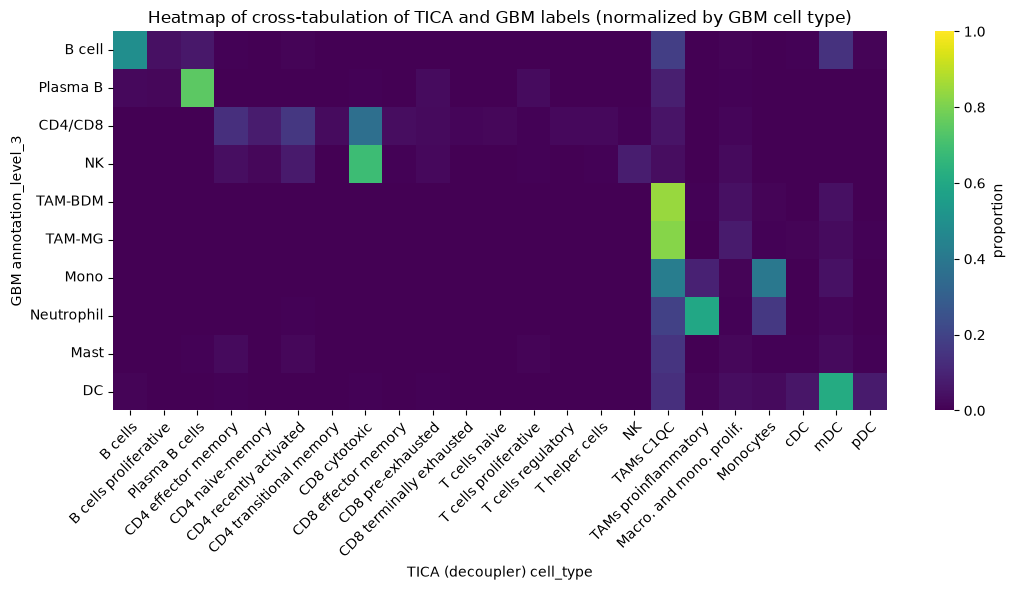

In [59]:
fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(ct_plot_row, annot=False, fmt=".2f", cmap="viridis", ax=ax, cbar_kws={"label": "proportion"}, vmin = 0, vmax=1)
ax.set_xlabel("TICA (decoupler) cell_type")
ax.set_ylabel("GBM annotation_level_3")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
ax.set_title("Heatmap of cross-tabulation of TICA and GBM labels (normalized by GBM cell type)")
plt.tight_layout()
plt.show()
out_pdf = os.path.join(OUT_DIR, "08_11_GBM_TICA_annotation_heatmap_1.pdf")
plt.savefig(out_pdf, bbox_inches="tight", dpi=300)
plt.close()

### 4. normalize for percentual accordance: per columns (TICA annotation)

In [49]:
ct_norm_col = ct.div(ct.sum(axis=0), axis=1)
ct_plot_col = ct_norm_col.reindex(columns=tica_order_present, 
                                  index=gbm_order_present)

checkpoint(f"Ordered GBM columns: {ct_plot_col.columns.tolist()}")

[2026-09-30 19:58:25] Ordered GBM columns: ['B cells', 'B cells proliferative', 'Plasma B cells', 'CD4 effector memory', 'CD4 naive-memory', 'CD4 recently activated', 'CD4 transitional memory', 'CD8 cytotoxic', 'CD8 effector memory', 'CD8 pre-exhausted', 'CD8 terminally exhausted', 'T cells naive', 'T cells proliferative', 'T cells regulatory', 'T helper cells', 'NK', 'TAMs C1QC', 'TAMs proinflammatory', 'Macro. and mono. prolif.', 'Monocytes', 'cDC', 'mDC', 'pDC']


In [50]:
adata.obs["decoupler_level1_celltype"].value_counts()

decoupler_level1_celltype
TAMs C1QC                   415273
CD8 cytotoxic                39221
Macrophages SPP1             28755
Macro. and mono. prolif.     27408
mDC                          24774
Monocytes                    20441
CD4 recently activated       16834
CD4 effector memory          14684
TAMs proinflammatory          8754
CD4 naive-memory              8056
CD8 effector memory           3604
CD8 pre-exhausted             3249
cDC                           3169
CD4 transitional memory       2864
pDC                           2715
T cells regulatory            2350
T helper cells                2349
T cells naive                 1799
CD8 terminally exhausted      1645
B cells                       1635
Plasma B cells                1549
NK                             819
T cells proliferative          710
Mast cells                     639
B cells proliferative          414
Name: count, dtype: int64

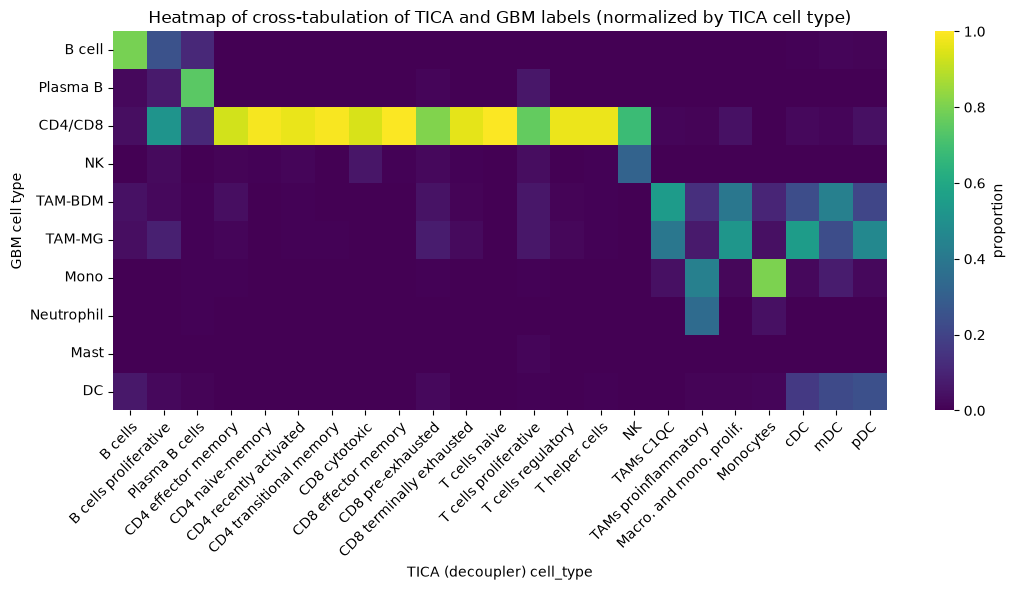

In [60]:
fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(ct_plot_col, annot=False, fmt=".2f", cmap="viridis", ax=ax, cbar_kws={"label": "proportion"}, vmin = 0, vmax=1) # ! sort
ax.set_xlabel("TICA (decoupler) cell_type")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
ax.set_ylabel("GBM cell type")
ax.set_title("Heatmap of cross-tabulation of TICA and GBM labels (normalized by TICA cell type)")

plt.tight_layout()
plt.show()
out_pdf = os.path.join(OUT_DIR, "08_11_GBM_TICA_annotation_heatmap_2.pdf")
plt.savefig(out_pdf, bbox_inches="tight", dpi=300)
plt.close()

In [56]:
checkpoint(f"adata.raw available: {adata.raw is not None}")
checkpoint(f"adata.X shape: {adata.shape}")

if adata.raw is not None:
    checkpoint(f"adata.raw shape: {adata.raw.shape}")

[2026-09-12 12:38:30] adata.raw available: True
[2026-09-12 12:38:30] adata.X shape: (129435, 32338)
[2026-09-12 12:38:30] adata.raw shape: (129435, 32357)


In [ ]:
sc.tl.rank_genes_groups(adata, groupby=gbm_col, reference="rest", method="wilcoxon", n_genes=adata.n_vars,  key_added="gbm_markers_wilcoxon", use_raw=False, pts=True)

/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/.environments/kaleidocell_env/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/.environments/kaleidocell_env/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/.environments/kaleidocell_env/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/.environments/kaleidocell_env/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[g

#### GBM cell type marker genes

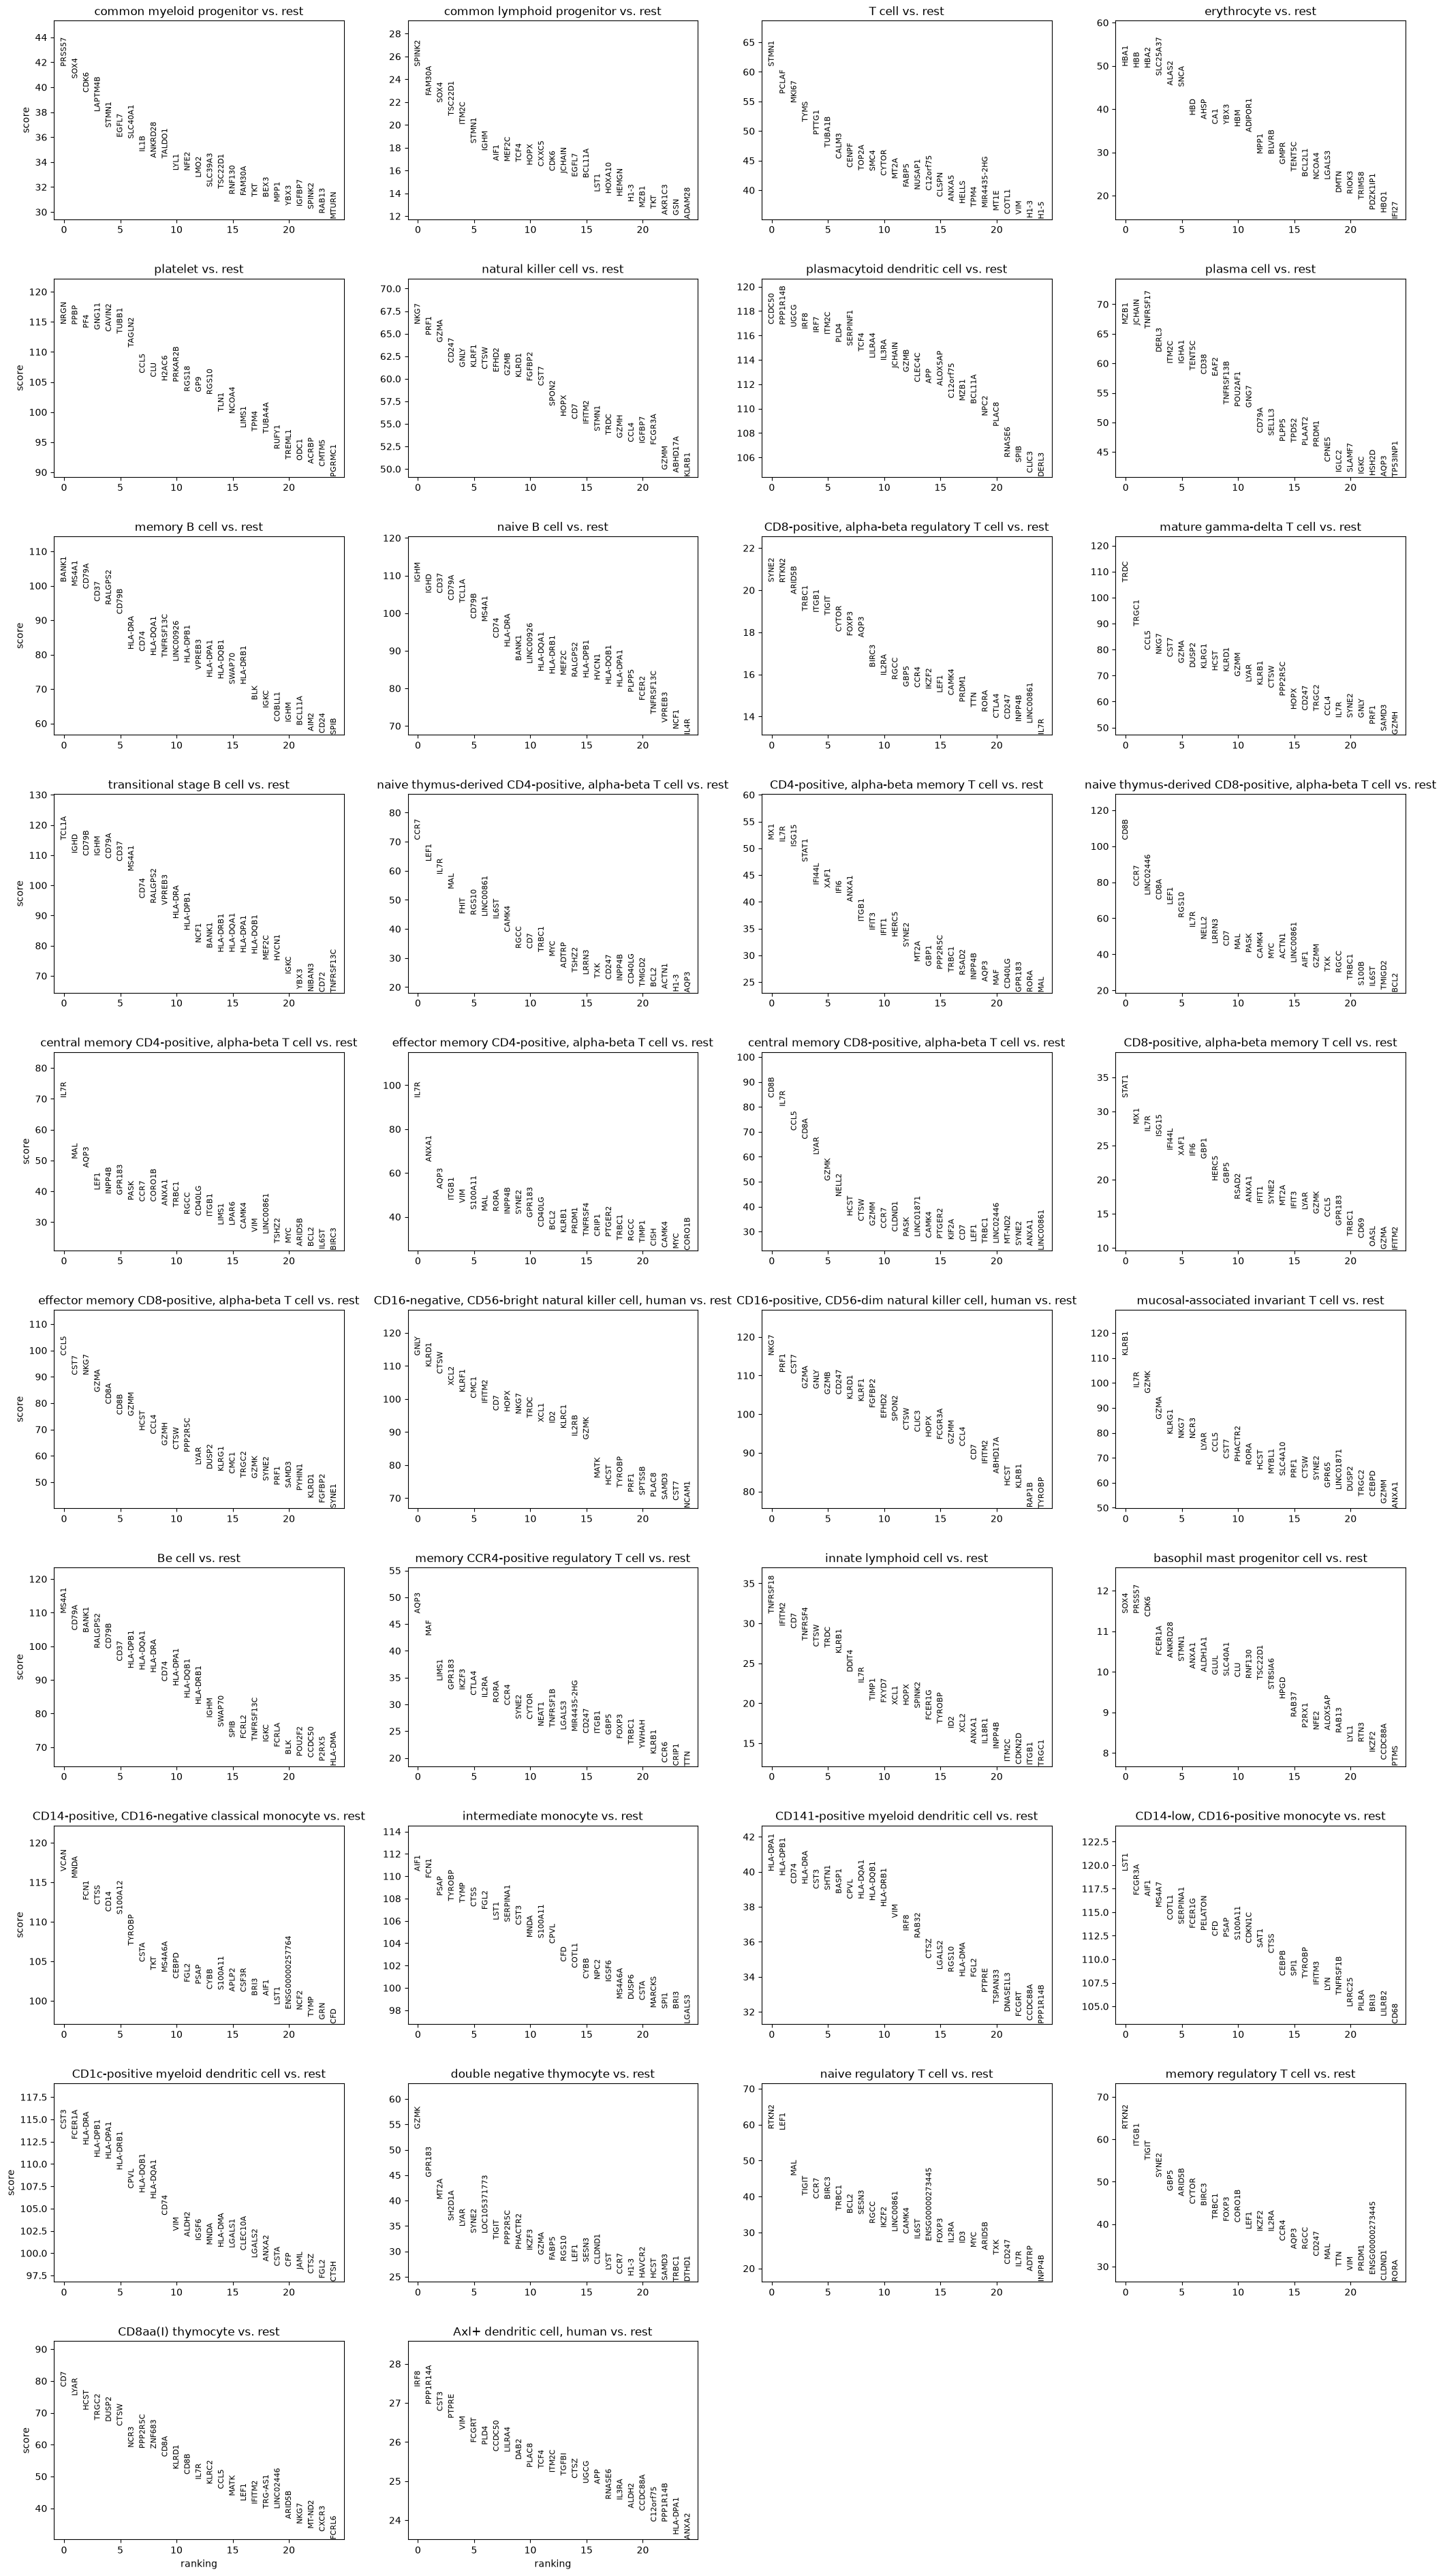

[2026-09-12 13:43:06] Saved HIHA markers plot to /net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/09_HIHAtlas/09_10_HIHA_markers_wilcoxon.pdf


In [ ]:
out_path = os.path.join(OUT_DIR, "08_11_GBM_markers_wilcoxon.pdf")
sc.pl.rank_genes_groups(adata, key="GBM_markers_wilcoxon", n_genes=25, sharey=False, show=False)
plt.savefig(out_path, bbox_inches="tight", dpi=300)
plt.show()
plt.close()
checkpoint(f"Saved GBM markers plot to {out_path}")

In [ ]:
group = "T cell"
markers_tcell = sc.get.rank_genes_groups_df(
    adata,
    group=group,
    key="GBM_markers_wilcoxon",
)
display(markers_tcell.head(15))

,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference
0,STMN1,60.892288,9.482586,0.0,0.0,1.0,1.0
1,PCLAF,56.272190,23.115393,0.0,0.0,1.0,1.0
2,MKI67,54.733887,21.476057,0.0,0.0,1.0,1.0
3,TYMS,51.552845,22.150434,0.0,0.0,1.0,1.0
4,PTTG1,49.346626,10.490596,0.0,0.0,1.0,1.0
5,TUBA1B,47.228729,5.706294,0.0,0.0,1.0,1.0
6,CALM3,45.278286,6.055053,0.0,0.0,1.0,1.0
7,CENPF,43.808250,13.109838,0.0,0.0,1.0,1.0
8,TOP2A,43.359722,18.568243,0.0,0.0,1.0,1.0
9,SMC4,43.218475,7.208865,0.0,0.0,1.0,1.0
